--- DECISION TREE REGRESYON SONUÇLARI ---
R2 Skoru: 0.9741
RMSE (Root Mean Squared Error): 20912.78

--- DECISION TREE SINIFLANDIRMA SONUÇLARI ---
Accuracy: 0.9531
Precision: 0.9143
Recall: 1.0000
F1-Score: 0.9552


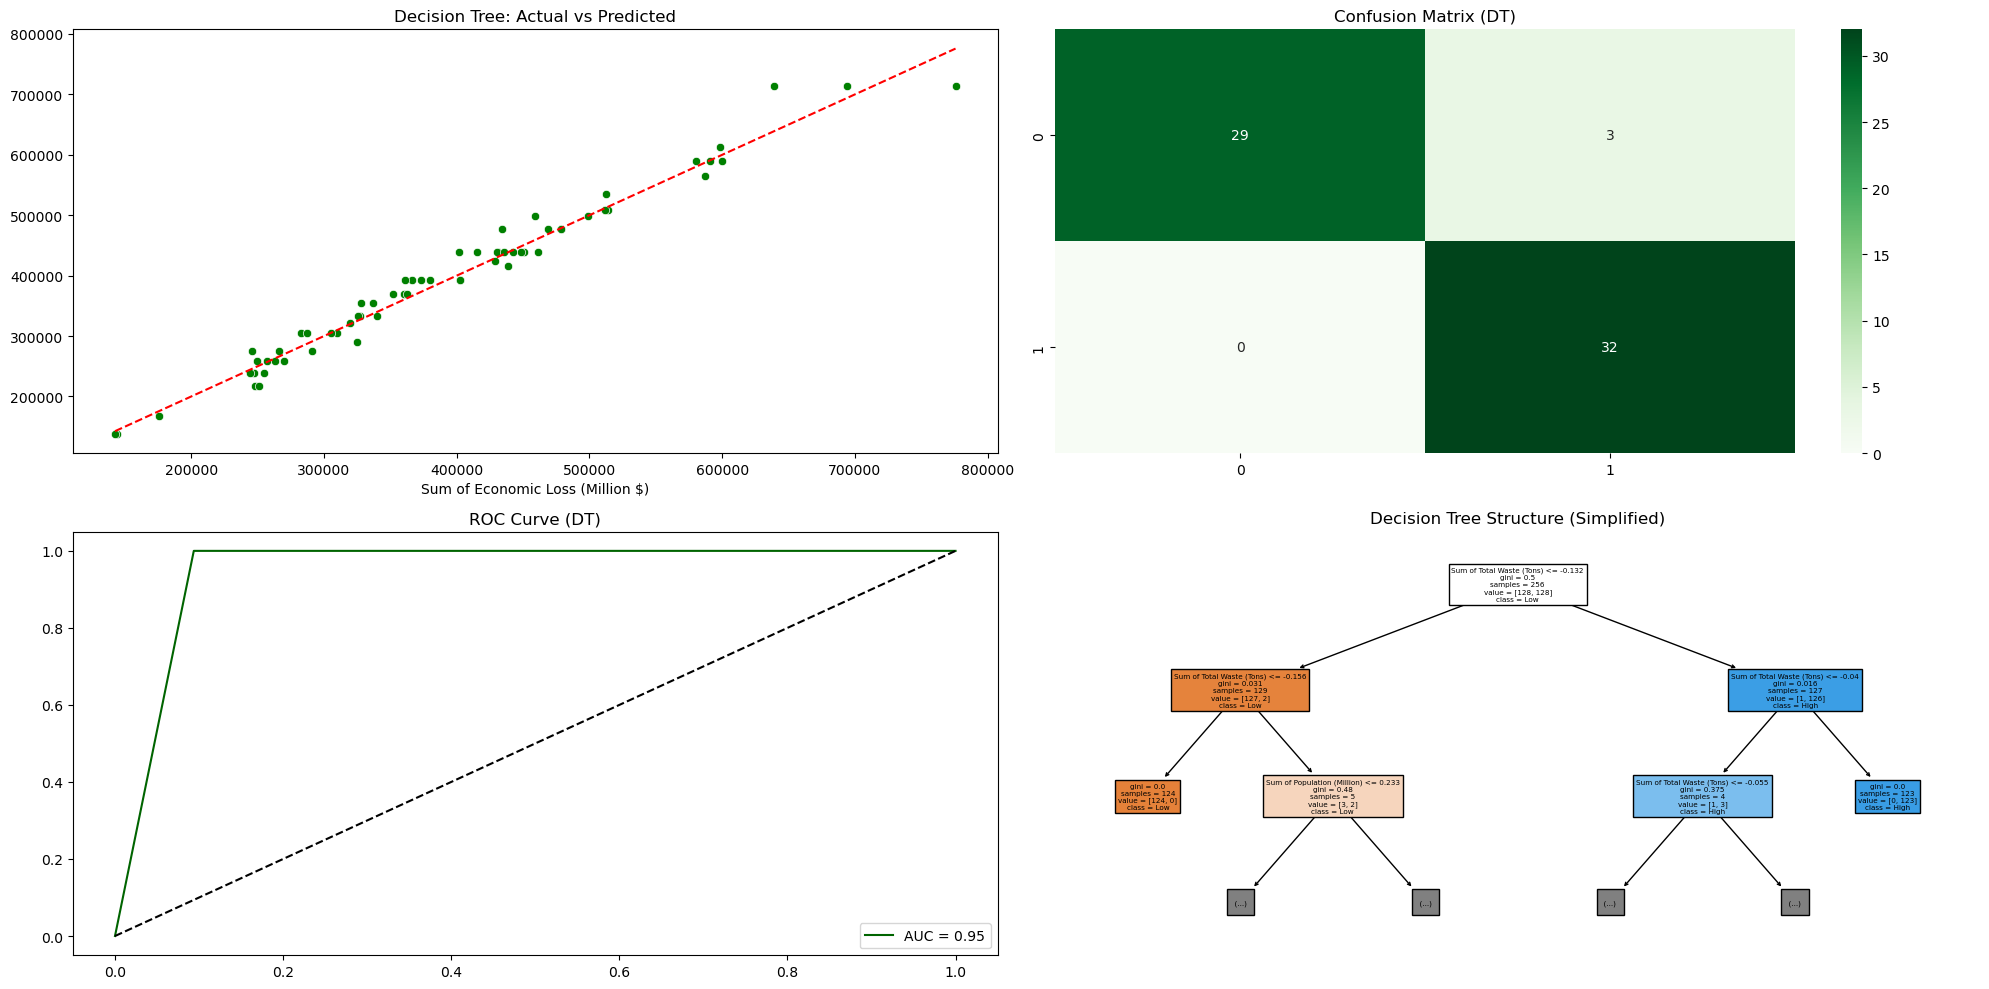

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import (mean_absolute_error, r2_score, mean_squared_error,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import StandardScaler

# 1. VERİ YÜKLEME
file_name = 'Linear Regression Cleaned Data.csv' 
df = pd.read_csv(file_name)

# 2. DATA PREPARATION
X = df.drop(['Sum of Economic Loss (Million $)', 'Food Category', 'Year Category'], axis=1)
# Ülkeleri sayısal (0-1) hale getiriyoruz (One-Hot Encoding)
X = pd.get_dummies(X, columns=['Country'], drop_first=True)

# Hedef Değişkenler
y_reg = df['Sum of Economic Loss (Million $)'] # Regresyon hedefi
y_clf = (y_reg > y_reg.median()).astype(int)   # Sınıflandırma hedefi (Yüksek/Düşük Risk)

# 3. SPLIT & SCALE
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# Decision Tree için scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. MODEL TRAINING (Decision Tree)
dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg.fit(X_train_scaled, y_train_reg)

# Sınıflandırma Modeli (Accuracy, ROC vb. için)
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X_train_scaled, y_train_clf)

# 5. EVALUATION
y_pred_reg = dt_reg.predict(X_test_scaled)
y_pred_clf = dt_clf.predict(X_test_scaled)
y_prob_clf = dt_clf.predict_proba(X_test_scaled)[:, 1]

print("--- DECISION TREE REGRESYON SONUÇLARI ---")
print(f"R2 Skoru: {r2_score(y_test_reg, y_pred_reg):.4f}")
print(f"RMSE (Root Mean Squared Error): {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):.2f}")

print("\n--- DECISION TREE SINIFLANDIRMA SONUÇLARI ---")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"Precision: {precision_score(y_test_clf, y_pred_clf):.4f}")
print(f"Recall: {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"F1-Score: {f1_score(y_test_clf, y_pred_clf):.4f}")

# 6. VISUALIZATIONS 
plt.figure(figsize=(20, 10))

# Plot 1: Error Plot (Regression)
plt.subplot(2, 2, 1)
sns.scatterplot(x=y_test_reg, y=y_pred_reg, color='green')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.title('Decision Tree: Actual vs Predicted')

# Plot 2: Confusion Matrix (Classification)
plt.subplot(2, 2, 2)
sns.heatmap(confusion_matrix(y_test_clf, y_pred_clf), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (DT)')

# Plot 3: ROC Curve (Classification)
plt.subplot(2, 2, 3)
fpr, tpr, _ = roc_curve(y_test_clf, y_prob_clf)
plt.plot(fpr, tpr, color='darkgreen', label=f'AUC = {auc(fpr, tpr):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (DT)')
plt.legend()

# Plot 4: Ağaç Yapısını Görselleştirme 
plt.subplot(2, 2, 4)
plot_tree(dt_clf, max_depth=2, feature_names=list(X.columns), class_names=['Low', 'High'], filled=True)
plt.title('Decision Tree Structure (Simplified)')

plt.tight_layout()
plt.show()